In [1]:
import os
import urllib.parse
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the hidden variables from the .env file
load_dotenv()


# 2. Build your connection engine
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

from pathlib import Path

# Step up to the project root and navigate into your target folder
sql_path = Path.cwd().parent / "queries" / "extract_movie_features.sql"

with open(sql_path, "r", encoding="utf-8") as file:
    query = file.read()

# 2. Execute query against database connection
df_raw = pd.read_sql(query, con=engine)

# 3. Create a clean working copy for Pandas transformations
df = df_raw.copy()

df.columns


Index(['movie_id', 'imdb_id', 'title', 'original_title', 'status',
       'original_language', 'adult', 'video', 'release_date', 'release_year',
       'release_month', 'release_day_of_week', 'budget', 'revenue',
       'net_profit', 'roi', 'runtime', 'movie_popularity', 'vote_average',
       'vote_count', 'collection_name', 'is_part_of_franchise',
       'primary_genre', 'primary_production_company', 'primary_country',
       'director_name', 'cast', 'overview', 'tagline'],
      dtype='str')

What are the most common words in title, overview, and tagline

In [2]:
# Find most common words in title, overview, and tagline
import re
from collections import Counter

# Try to use scikit-learn stop words, fallback to a small list if unavailable
try:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as SK_STOP
except Exception:
    SK_STOP = set([
        'the','and','a','of','to','in','is','it','that','as','for','with','on','by','an','be','this','from','are','at','or','its'
    ])

def tokenize(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = [t for t in text.split() if t not in SK_STOP and len(t) > 1 and not t.isdigit()]
    return tokens

def top_words(series, top_n=30):
    cnt = Counter()
    for val in series.dropna().astype(str):
        cnt.update(tokenize(val))
    return cnt.most_common(top_n)

for col in ['title','overview','tagline']:
    if col in df.columns:
        print(f'--- Top words for {col} ---')
        top = top_words(df[col], top_n=30)
        display(pd.DataFrame(top, columns=['word','count']))
    else:
        print(f'Column {col} not found in dataframe')

# Combined fields
if all(c in df.columns for c in ['title','overview','tagline']):
    combined = df[['title','overview','tagline']].fillna('').agg(' '.join, axis=1)
    print('--- Top words for combined text (title+overview+tagline) ---')
    top_comb = top_words(combined, top_n=50)
    display(pd.DataFrame(top_comb, columns=['word','count']))
else:
    print('One or more combined columns are missing; skipping combined analysis')


--- Top words for title ---


,word,count
0,man,139
1,movie,98
2,ii,80
3,love,73
4,night,63
5,day,58
6,life,55
7,dead,52
8,black,50
9,king,47


--- Top words for overview ---


,word,count
0,life,1363
1,new,1157
2,young,1005
3,world,977
4,family,938
5,man,817
6,love,688
7,old,560
8,finds,555
9,years,554


--- Top words for tagline ---


,word,count
0,love,360
1,world,299
2,life,282
3,story,270
4,man,268
5,time,212
6,just,198
7,new,181
8,family,138
9,adventure,133


--- Top words for combined text (title+overview+tagline) ---


,word,count
0,life,1700
1,new,1382
2,world,1323
3,man,1224
4,love,1121
5,family,1098
6,young,1042
7,time,758
8,story,754
9,years,627


Are franchises more successful than standalone movies

,type,count,mean_revenue_m,median_revenue_m,mean_budget_m,mean_roi,median_roi
0,standalone,5843,58.380268,23.530831,27.372468,3.486243,1.724690
1,franchise,2197,187.815973,74.189677,45.324678,6.288695,3.504545


Revenue t-test: t=20.532, p=0.00000
ROI Mann-Whitney U test p=0.00000


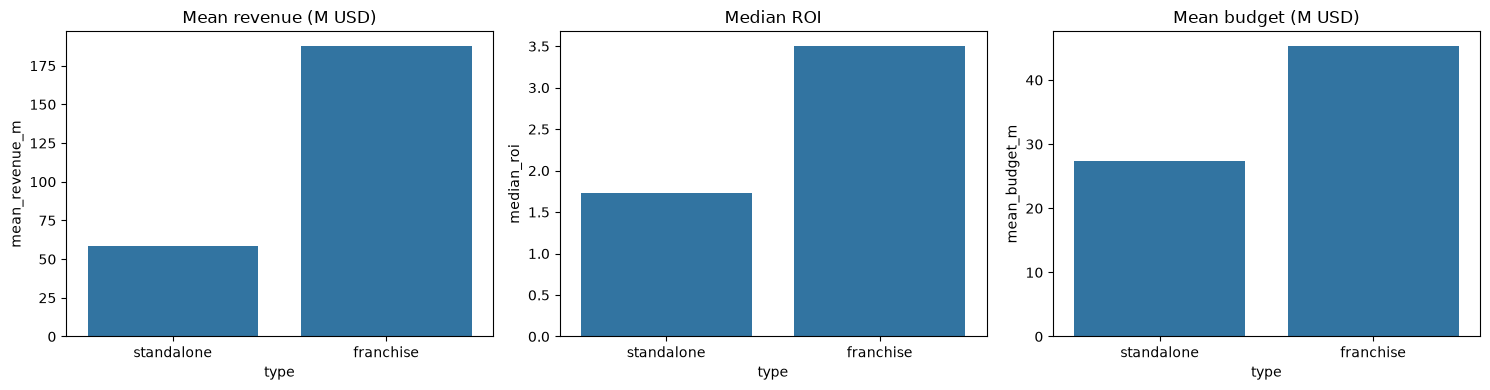

In [3]:
# Compare franchise vs standalone movies: mean revenue, median ROI, mean budget
import numpy as np
from scipy import stats

# Ensure numeric columns exist and derive convenient metrics
for c in ['budget','revenue','roi']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'revenue_m' not in df.columns and 'revenue' in df.columns:
    df['revenue_m'] = df['revenue'] / 1e6
if 'budget_m' not in df.columns and 'budget' in df.columns:
    df['budget_m'] = df['budget'] / 1e6
if 'roi' not in df.columns and 'revenue' in df.columns and 'budget' in df.columns:
    df['roi'] = np.where(df['budget'] > 0, df['revenue'] / df['budget'], np.nan)

if 'is_part_of_franchise' in df.columns:
    df['is_part_of_franchise'] = pd.to_numeric(df['is_part_of_franchise'], errors='coerce').fillna(0).astype(int)

    grp = df.groupby('is_part_of_franchise').agg(
        count=('movie_id','count') if 'movie_id' in df.columns else ('title','count'),
        mean_revenue_m=('revenue_m','mean'),
        median_revenue_m=('revenue_m','median'),
        mean_budget_m=('budget_m','mean'),
        mean_roi=('roi','mean'),
        median_roi=('roi','median')
    ).reset_index()
    grp['type'] = grp['is_part_of_franchise'].map({1:'franchise',0:'standalone'})

    display(grp[['type','count','mean_revenue_m','median_revenue_m','mean_budget_m','mean_roi','median_roi']])

    # Statistical comparisons
    a_rev = df.loc[df['is_part_of_franchise']==1, 'revenue_m'].dropna()
    b_rev = df.loc[df['is_part_of_franchise']==0, 'revenue_m'].dropna()
    if len(a_rev) > 1 and len(b_rev) > 1:
        tstat, p_rev = stats.ttest_ind(a_rev, b_rev, equal_var=False, nan_policy='omit')
        print(f'Revenue t-test: t={tstat:.3f}, p={p_rev:.5f}')
    else:
        print('Not enough data for revenue t-test')

    a_roi = df.loc[df['is_part_of_franchise']==1, 'roi'].dropna()
    b_roi = df.loc[df['is_part_of_franchise']==0, 'roi'].dropna()
    if len(a_roi) > 0 and len(b_roi) > 0:
        try:
            u_stat, p_roi = stats.mannwhitneyu(a_roi, b_roi, alternative='two-sided')
            print(f'ROI Mann-Whitney U test p={p_roi:.5f}')
        except Exception as e:
            print('ROI Mann-Whitney test failed:', e)
    else:
        print('Not enough ROI data for nonparametric test')

    # Plots
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    sns.barplot(x='type', y='mean_revenue_m', data=grp, ax=axes[0])
    axes[0].set_title('Mean revenue (M USD)')

    sns.barplot(x='type', y='median_roi', data=grp, ax=axes[1])
    axes[1].set_title('Median ROI')

    sns.barplot(x='type', y='mean_budget_m', data=grp, ax=axes[2])
    axes[2].set_title('Mean budget (M USD)')

    plt.tight_layout()
    plt.show()

else:
    print('Column `is_part_of_franchise` not found in dataframe; cannot compare')


Top franchise

In [4]:
# Most successful franchises by count, total and mean budget/revenue
# Groups by `collection_name` for movies marked as part of a franchise
from IPython.display import display

if 'is_part_of_franchise' in df.columns and 'collection_name' in df.columns:
    idcol = 'movie_id' if 'movie_id' in df.columns else 'title'
    fr = df[df['is_part_of_franchise'] == 1].copy()
    fr['collection_name'] = fr['collection_name'].fillna('Unknown').astype(str).str.strip()

    grp = fr.groupby('collection_name').agg(
        n_movies=(idcol, 'count'),
        total_budget=('budget', 'sum'),
        mean_budget=('budget', 'mean'),
        total_revenue=('revenue', 'sum'),
        mean_revenue=('revenue', 'mean')
    ).reset_index()

    # Convert to millions for readability
    grp['total_budget_m'] = grp['total_budget'] / 1e6
    grp['mean_budget_m'] = grp['mean_budget'] / 1e6
    grp['total_revenue_m'] = grp['total_revenue'] / 1e6
    grp['mean_revenue_m'] = grp['mean_revenue'] / 1e6

    # Sort and display top franchises by total_revenue and by count
    top_by_revenue = grp.sort_values('total_revenue', ascending=False).head(20)
    top_by_count = grp.sort_values('n_movies', ascending=False).head(20)

    print('--- Top franchises by total revenue ---')
    display(top_by_revenue[[ 'collection_name', 'n_movies', 'total_revenue_m', 'mean_revenue_m', 'total_budget_m', 'mean_budget_m' ]].rename(columns={
        'collection_name':'Collection', 'n_movies':'# Movies', 'total_revenue_m':'Total Revenue (M)', 'mean_revenue_m':'Mean Revenue (M)',
        'total_budget_m':'Total Budget (M)', 'mean_budget_m':'Mean Budget (M)'
    }))

    print('\n--- Top franchises by number of movies ---')
    display(top_by_count[[ 'collection_name', 'n_movies', 'total_revenue_m', 'mean_revenue_m', 'total_budget_m', 'mean_budget_m' ]].rename(columns={
        'collection_name':'Collection', 'n_movies':'# Movies', 'total_revenue_m':'Total Revenue (M)', 'mean_revenue_m':'Mean Revenue (M)',
        'total_budget_m':'Total Budget (M)', 'mean_budget_m':'Mean Budget (M)'
    }))

else:
    print('Required columns `is_part_of_franchise` and/or `collection_name` missing; cannot compute franchises')


--- Top franchises by total revenue ---


,Collection,# Movies,Total Revenue (M),Mean Revenue (M),Total Budget (M),Mean Budget (M)
823,Star Wars Collection,9,8909.187322,989.909702,1444.25,160.472222
465,James Bond Collection,26,7807.050254,300.271164,1785.70,68.680769
876,The Avengers Collection,4,7776.073348,1944.018337,1111.00,277.750000
386,Harry Potter Collection,8,7759.777709,969.972214,1280.00,160.000000
926,The Fast and the Furious Collection,11,7323.001618,665.727420,1749.00,159.000000
488,Jurassic Park Collection,7,6901.031300,985.861614,1387.80,198.257143
92,Avatar Collection,3,6744.190536,2248.063512,1047.00,349.000000
808,Spider-Man (MCU) Collection,4,6155.028510,1538.757128,760.00,190.000000
596,Mission: Impossible Collection,8,4774.057878,596.757235,1448.00,181.000000
1092,Toy Story Collection,5,4716.175842,943.235168,745.00,149.000000



--- Top franchises by number of movies ---


,Collection,# Movies,Total Revenue (M),Mean Revenue (M),Total Budget (M),Mean Budget (M)
465,James Bond Collection,26,7807.050254,300.271164,1785.70,68.680769
926,The Fast and the Furious Collection,11,7323.001618,665.727420,1749.00,159.000000
332,Friday the 13th Collection,11,355.909442,32.355404,63.70,5.790909
555,Madea Collection,11,670.604952,60.964087,203.00,18.454545
377,Halloween Collection,10,695.935213,69.593521,111.00,11.100000
750,Saw Collection,10,1155.473565,115.547357,107.00,10.700000
823,Star Wars Collection,9,8909.187322,989.909702,1444.25,160.472222
386,Harry Potter Collection,8,7759.777709,969.972214,1280.00,160.000000
596,Mission: Impossible Collection,8,4774.057878,596.757235,1448.00,181.000000
1168,X-Men Collection,7,3061.458216,437.351174,1183.00,169.000000


In [5]:
# 1. Ensure the column is in datetime format
df['release_date'] = pd.to_datetime(df['release_date'])

# 2. Extract year, count movies, and convert to a clean table
yearly_counts = df['release_date'].dt.year.value_counts().sort_index().reset_index()

# 3. Rename columns for clarity
yearly_counts.columns = ['Year', 'Movie Count']

# Display the table
print(yearly_counts)


    Year  Movie Count
0   1925            1
1   1926            1
2   1927            1
3   1930            1
4   1931            1
..   ...          ...
93  2023          189
94  2024          198
95  2025          200
96  2026          124
97  2027            1

[98 rows x 2 columns]


In [7]:
df['budget'].head()

0     4000000
1    21000000
2    11000000
3    94000000
4    55000000
Name: budget, dtype: int64

In [10]:
# 3. Create a dynamic ceiling for bins based on the maximum budget in your data
max_budget = df["budget"].max()
# Generates intervals of 50M up to the absolute highest budget in your file
bin_edges = list(range(0, int(max_budget) + 50_000_000, 50_000_000))
if bin_edges[-1] < max_budget:
    bin_edges.append(np.inf)

# 4. Automatically generate human-readable labels for the 50M intervals
labels = [
    f"${bin_edges[i]//1_000_000}M-${bin_edges[i+1]//1_000_000}M"
    for i in range(len(bin_edges) - 1)
]
# Clean up the final label if it ends at infinity
if bin_edges[-1] == np.inf:
    labels[-1] = f"${bin_edges[-2]//1_000_000}M+"

# 5. Segment every single movie into its respective 50M tier
df["budget_tier"] = pd.cut(df["budget"], bins=bin_edges, labels=labels)

# 6. Group and aggregate BOTH average ROI and movie count simultaneously
roi_distribution = (
    df.groupby("budget_tier", observed=False)
    .agg(
        average_roi=("roi", "mean"),
        total_movies=("roi", "count")
    )
    .reset_index()
)

# 7. Format and display the raw structured table
# Make numbers pretty for printing while keeping raw columns intact if needed
print_table = roi_distribution.copy()
print_table["average_roi"] = print_table["average_roi"].round(1).astype(str) + "%"
print_table["total_movies"] = print_table["total_movies"].apply(lambda x: f"{x:,}")

# Clean up console headers
print_table.columns = ["Budget Tier", "Average ROI", "Total Movies"]

print(f"Dataset Size: {len(df):,} total movies processed.\n")
print(print_table.to_string(index=False))


Dataset Size: 8,040 total movies processed.

Budget Tier Average ROI Total Movies
   $0M-$50M        4.6%        6,628
 $50M-$100M        2.6%          906
$100M-$150M        3.1%          273
$150M-$200M        3.1%          166
$200M-$250M        3.7%           44
$250M-$300M        2.9%           14
$300M-$350M        2.6%            3
$350M-$400M        4.0%            3
$400M-$450M         NaN            0
$450M-$500M        3.6%            2
$500M-$550M         NaN            0
$550M-$600M         NaN            0
$600M-$650M         NaN            0
$650M-$700M        1.5%            1
